# Train a Waveform Generator

In [1]:
import torch
from spectrogan import WaveformGenerator, WaveformDiscriminator, SpectrogramDiscriminator, train_loop, load_data, Config
from specforge import CustomFeatureExtractor
from dataclasses import dataclass, asdict

config = Config(
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    
    # Training
    train_splits        = (1,2,3,4),
    test_split          = 5,
    batch_size          = 64,
    epochs              = 100,
    steps_per_epoch     = 100,
    
    # Spectrogram
    window_size_secs    = 2,
    sample_rate         = 16000,
    spec_freq_dim       = 120,
    spec_time_dim       = 240,
    
    # GAN
    nz                  = 128,
    lr_g                = 2e-4,
    lr_dw               = 1e-4,
    lr_ds               = 1e-4,
    lam_d               = 0.5, #waveform to spec discriminator loss ratio
    lam_g               = 0.5, #waveform to spec generator loss ratio
    k                   = 1,
    noise_strength      = 0.05,
    betas               = (0.5, 0.999),
)

# Load data
train_gen, test_gen, data_folder = load_data(
    config.train_splits,
    config.test_split,
    config.batch_size,
    config.window_size_secs
)

# Models
data_length = config.sample_rate * config.window_size_secs
G = WaveformGenerator(config.nz, data_length).to(config.device)
DW = WaveformDiscriminator().to(config.device)
DS = SpectrogramDiscriminator().to(config.device)

optim_g = torch.optim.Adam(G.parameters(), lr=config.lr_g, betas=config.betas)
optim_dw = torch.optim.Adam(DW.parameters(), lr=config.lr_dw, betas=config.betas)
optim_ds = torch.optim.Adam(DS.parameters(), lr=config.lr_ds, betas=config.betas)

#Instantiate Feature Extractor
extractor = CustomFeatureExtractor.from_sample_rate(
    sample_rate=config.sample_rate,
    window_length=config.window_size_secs,
    spec_freq_dim=config.spec_freq_dim,
    spec_time_dim=config.spec_time_dim,
).to(config.device)

100%|█████████████████████████████████████████| 100/100 [01:07<00:00,  1.48it/s]


Epoch 0: G=0.5677216649055481, D=2.3191075325012207


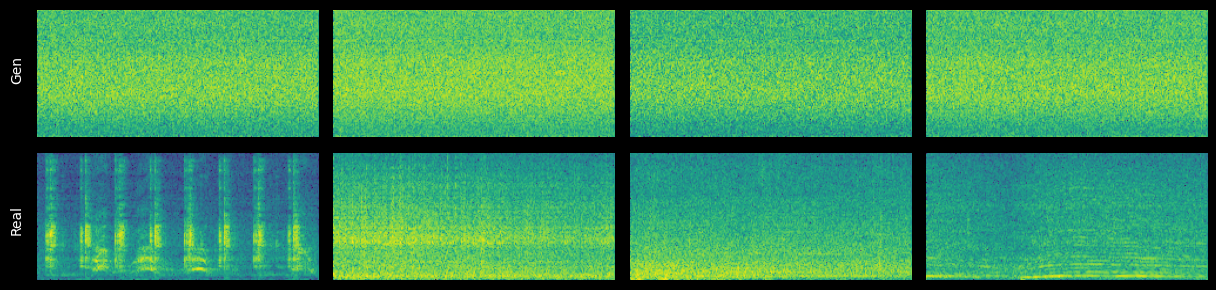

100%|█████████████████████████████████████████| 100/100 [01:07<00:00,  1.49it/s]


Epoch 1: G=0.8621718287467957, D=1.567527174949646


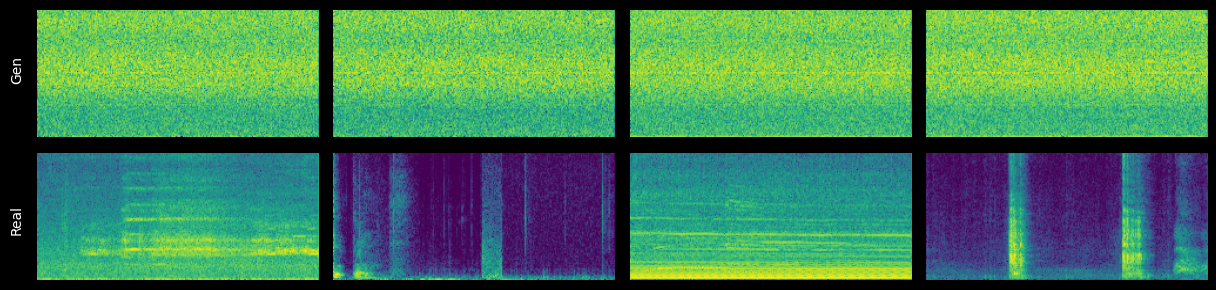

  3%|█▎                                         | 3/100 [00:02<01:04,  1.50it/s]

In [ ]:
# Train
losses_g, losses_d = train_loop(G, DW, DS, train_gen, extractor, optim_g, optim_dw, optim_ds, config, save_folder="model")